# Enhanced PPO — Autonomous Highway Driving
### Full Pipeline Notebook

Run each cell **in order**. Every step shows output so you can follow along.

| Step | What happens |
|------|--------------|
| 1 | Install dependencies |
| 2 | Imports & configuration |
| 3 | Verify the environment works |
| 4 | Train the **baseline** model |
| 5 | Train the **enhanced** model (all 5 enhancements) |
| 6 | Evaluate both models — compute all 8 metrics |
| 7 | Generate & display comparison plots |
| 8 | Print the final summary table |

---
## Step 1 — Install dependencies

In [ ]:
# Install all required packages
import subprocess, sys

packages = [
    'gymnasium>=0.29.0',
    'stable-baselines3>=2.0.0',
    'highway-env>=1.8.0',
    'torch>=2.0.0',
    'pygame>=2.5.0',
    'seaborn>=0.12.0',
    'numpy>=1.24.0',
    'tensorboard>=2.13.0',
    'matplotlib',
]

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg])

print('All packages installed.')

---
## Step 2 — Imports & configuration
This cell imports everything and sets the enhancement toggle flags.  
Set any flag to `False` to disable that enhancement (useful for ablation studies).

In [4]:
import os, sys
import numpy as np
import torch
import gymnasium as gym
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Agg')   # works headless on Colab
from IPython.display import display, Image

# Make sure the project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import highway_env  # noqa — registers highway-v0

from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback

from src.models.baseline_model import CustomExtractor, env_kwargs
from src.envs.custom_wrappers import (
    EnhancedRewardWrapper,
    DynamicTrafficWrapper,
    ObservationEnrichmentWrapper,
)
from src.models.custom_policy import AttentionRegularizedPPO
from src.evaluation.evaluation_metrics import (
    MetricsEvaluator, MetricsPlotter, compute_learning_efficiency
)
from src.training.hyperparameter_search import random_search, print_ranked_results

# -----------------------------------------------------------------------
# Enhancement toggles — set to False to disable for ablation studies
# -----------------------------------------------------------------------
ENHANCEMENTS = {
    'enhanced_reward':        True,   # Enhancement 1: TTC + smooth + lane-center reward
    'dynamic_traffic':        True,   # Enhancement 2: sparse / moderate / dense traffic
    'observation_enrichment': True,   # Enhancement 3: 7 → 10 features per vehicle
    'attention_reg':          True,   # Enhancement 4: attention entropy regularization
    'hp_search':              False,  # Enhancement 5: set True to run HP search first
}

# -----------------------------------------------------------------------
# Training config
# -----------------------------------------------------------------------
TOTAL_TIMESTEPS = 200_000   # change to 50_000 for a quick test run
N_CPU           = 2         # parallel envs (use 1 on Colab free tier)
N_EVAL_EPISODES = 100       # episodes for metric evaluation
SEED            = 42
LOG_DIR         = '../enhanced_ppo_logs'
RESULTS_DIR     = '../results'

os.makedirs(LOG_DIR,     exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {DEVICE}')
print(f'Active enhancements: {[k for k,v in ENHANCEMENTS.items() if v]}')

Device : cpu
Active enhancements: ['enhanced_reward', 'dynamic_traffic', 'observation_enrichment', 'attention_reg']


---
## Step 3 — Verify the environment
We run a few random steps to confirm highway-env loads correctly and the observations look right.

In [5]:
# --- Test the BASELINE environment ---
test_env = gym.make('highway-v0', config=env_kwargs['config'])
obs, info = test_env.reset()

print('Baseline environment')
print(f'  Observation shape : {obs.shape}   (vehicles × features)')
print(f'  Action space      : {test_env.action_space}')
print(f'  First obs row     : {obs[0].round(3)}')
test_env.close()

# --- Test the ENHANCED environment ---
from scripts.train_enhanced import make_enhanced_env

test_env_enh = make_enhanced_env(enhancements=ENHANCEMENTS, **env_kwargs)
obs_enh, info_enh = test_env_enh.reset()

print('\nEnhanced environment')
print(f'  Observation shape : {obs_enh.shape}   (vehicles × features, now 10)')
print(f'  Traffic scenario  : {info_enh.get("traffic_scenario", "N/A")}')
print(f'  Vehicles count    : {info_enh.get("vehicles_count", "N/A")}')

# Take one step and check reward info
action = test_env_enh.action_space.sample()
obs_enh, reward, term, trunc, step_info = test_env_enh.step(action)
print(f'  Reward            : {reward:.4f}')
print(f'  TTC penalty       : {step_info.get("ttc_penalty", "N/A")}')
print(f'  Smooth reward     : {step_info.get("smooth_reward", "N/A")}')
print(f'  Lane-center reward: {step_info.get("lane_centering_reward", "N/A")}')
test_env_enh.close()

print('\nEnvironment check passed.')

Baseline environment
  Observation shape : (10, 7)   (vehicles × features)
  Action space      : Discrete(5)
  First obs row     : [1.    1.    0.667 0.312 0.    1.    0.   ]

Enhanced environment
  Observation shape : (10, 10)   (vehicles × features, now 10)
  Traffic scenario  : sparse
  Vehicles count    : 7
  Reward            : 0.9749
  TTC penalty       : 0.0
  Smooth reward     : 0.0
  Lane-center reward: 0.1

Environment check passed.


---
## Step 4 — Train the Baseline model
Standard PPO with the attention-based feature extractor. No enhancements.

In [6]:
import json
from scripts.train_enhanced import make_baseline_env, _BASELINE_ATTN_KWARGS

BASELINE_SAVE = os.path.join(LOG_DIR, 'baseline_model')
BASELINE_REWARD_LOG_PATH = os.path.join(LOG_DIR, 'baseline_reward_log.json')

baseline_reward_log = []

class _LogRewards(BaseCallback):
    """Captures mean reward every 20 episodes for the learning curve."""
    def __init__(self, reward_log, save_path, verbose=0):
        super().__init__(verbose)
        self.reward_log = reward_log
        self.save_path = save_path
        self._ep_rewards = []
    def _on_step(self):
        for info in self.locals.get('infos', []):
            if 'episode' in info:
                self._ep_rewards.append(info['episode']['r'])
        if len(self._ep_rewards) % 20 == 0 and self._ep_rewards:
            self.reward_log.append(np.mean(self._ep_rewards[-20:]))
            # Save to disk every 20 episodes so a crash doesn't lose progress
            with open(self.save_path, 'w') as f:
                json.dump(self.reward_log, f)
        return True

baseline_env = make_vec_env(
    make_baseline_env,
    n_envs=N_CPU,
    seed=SEED,
    vec_env_cls=DummyVecEnv,
    env_kwargs=env_kwargs,
)

baseline_model = PPO(
    'MlpPolicy',
    baseline_env,
    n_steps=max(512 // N_CPU, 64),
    batch_size=64,
    learning_rate=2e-3,
    policy_kwargs=dict(
        features_extractor_class=CustomExtractor,
        features_extractor_kwargs=_BASELINE_ATTN_KWARGS,
    ),
    verbose=1,
    device=DEVICE,
    tensorboard_log=os.path.join(LOG_DIR, 'baseline_tb'),
)

print(f'Training baseline for {TOTAL_TIMESTEPS:,} timesteps…')
baseline_model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[
        _LogRewards(baseline_reward_log, BASELINE_REWARD_LOG_PATH),
        CheckpointCallback(
            save_freq=50_000,
            save_path=os.path.join(LOG_DIR, 'baseline_ckpts'),
        ),
    ],
)

baseline_model.save(BASELINE_SAVE)
baseline_env.close()

# Save final reward log
with open(BASELINE_REWARD_LOG_PATH, 'w') as f:
    json.dump(baseline_reward_log, f)

print(f'\nBaseline saved        → {BASELINE_SAVE}.zip')
print(f'Reward log saved      → {BASELINE_REWARD_LOG_PATH}')
print(f'Reward log length     : {len(baseline_reward_log)} entries')

Using cpu device
Training baseline for 50,000 timesteps…
Logging to ../enhanced_ppo_logs/baseline_tb/PPO_2
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 22.8     |
|    ep_rew_mean     | 17.1     |
| time/              |          |
|    fps             | 87       |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 512      |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 21.2         |
|    ep_rew_mean          | 16.3         |
| time/                   |              |
|    fps                  | 87           |
|    iterations           | 2            |
|    time_elapsed         | 11           |
|    total_timesteps      | 1024         |
| train/                  |              |
|    approx_kl            | 0.0072364607 |
|    clip_fraction        | 0.224        |
|    clip_range           | 0.2      

---
## Step 5 — Train the Enhanced model

Each active enhancement is applied in order:
- **Enhancement 1** → `EnhancedRewardWrapper` adds TTC penalty + smooth + lane-center signals  
- **Enhancement 2** → `DynamicTrafficWrapper` randomises vehicle density + injects events  
- **Enhancement 3** → `ObservationEnrichmentWrapper` extends observation from 7 → 10 features  
- **Enhancement 4** → `AttentionRegularizedPPO` adds entropy penalty on attention after each epoch  
- **Enhancement 5** → `random_search` finds best hyperparameters before full training (optional)

In [17]:
from scripts.train_enhanced import make_enhanced_env, _ENHANCED_ATTN_KWARGS

ENHANCED_SAVE = os.path.join(LOG_DIR, 'enhanced_model')
enhanced_reward_log = []

# -----------------------------------------------------------------------
# Enhancement 5 — Hyperparameter search (optional)
# -----------------------------------------------------------------------
if ENHANCEMENTS['hp_search']:
    print('Running hyperparameter search (Enhancement 5)…')
    best_hp, hp_results = random_search(
        env_fn=lambda: make_enhanced_env(enhancements=ENHANCEMENTS, **env_kwargs),
        n_configs=12,
        total_timesteps=30_000,
        log_dir=os.path.join(LOG_DIR, 'hp_search'),
        seed=SEED,
    )
    print_ranked_results(hp_results, top_n=5)
    lr         = best_hp['learning_rate']
    batch_size = best_hp['batch_size']
    n_steps    = best_hp['n_steps']
    ent_coef   = best_hp['ent_coef']
    gamma      = best_hp['gamma']
else:
    lr, batch_size, n_steps, ent_coef, gamma = 2e-3, 64, 512, 0.01, 0.99

print(f'Hyperparameters: lr={lr}, batch={batch_size}, n_steps={n_steps}, ent={ent_coef}, γ={gamma}')

# -----------------------------------------------------------------------
# Choose attention kwargs based on whether observation is enriched (10 vs 7 features)
# -----------------------------------------------------------------------
attn_kwargs = (
    _ENHANCED_ATTN_KWARGS
    if ENHANCEMENTS['observation_enrichment']
    else _BASELINE_ATTN_KWARGS
)

enhanced_env = make_vec_env(
    make_enhanced_env,
    n_envs=N_CPU,
    seed=SEED,
    vec_env_cls=DummyVecEnv,
    env_kwargs={'enhancements': ENHANCEMENTS, **env_kwargs},
)

# -----------------------------------------------------------------------
# Enhancement 4 — AttentionRegularizedPPO vs standard PPO
# -----------------------------------------------------------------------
ModelClass = AttentionRegularizedPPO if ENHANCEMENTS['attention_reg'] else PPO
print(f'Model class: {ModelClass.__name__}')

model_kwargs = dict(
    policy='MlpPolicy',
    env=enhanced_env,
    n_steps=max(n_steps // N_CPU, batch_size),
    batch_size=batch_size,
    learning_rate=lr,
    ent_coef=ent_coef,
    gamma=gamma,
    policy_kwargs=dict(
        features_extractor_class=CustomExtractor,
        features_extractor_kwargs=attn_kwargs,
    ),
    verbose=1,
    device=DEVICE,
    tensorboard_log=os.path.join(LOG_DIR, 'enhanced_tb'),
)
if ENHANCEMENTS['attention_reg']:
    model_kwargs.update(lambda_high=0.01, lambda_low=0.01,
                        n_observed_vehicles=10, enable_attention_reg=True)

enhanced_model = ModelClass(**model_kwargs)

print(f'\nTraining enhanced model for {TOTAL_TIMESTEPS:,} timesteps…')
enhanced_model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[
        _LogRewards(enhanced_reward_log, ENHANCED_REWARD_LOG_PATH),
        CheckpointCallback(
            save_freq=50_000,
            save_path=os.path.join(LOG_DIR, 'enhanced_ckpts'),
        ),
    ],
)

enhanced_model.save(ENHANCED_SAVE)
enhanced_env.close()
print(f'\nEnhanced model saved → {ENHANCED_SAVE}.zip')

Hyperparameters: lr=0.002, batch=64, n_steps=512, ent=0.01, γ=0.99
Model class: AttentionRegularizedPPO
Using cpu device

Training enhanced model for 50,000 timesteps…
Logging to ../enhanced_ppo_logs/enhanced_tb/PPO_1
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 16.7     |
|    ep_rew_mean     | 14.6     |
| time/              |          |
|    fps             | 72       |
|    iterations      | 1        |
|    time_elapsed    | 7        |
|    total_timesteps | 512      |
---------------------------------
-----------------------------------------
| rollout/                  |           |
|    ep_len_mean            | 19.9      |
|    ep_rew_mean            | 17.1      |
| time/                     |           |
|    fps                    | 68        |
|    iterations             | 2         |
|    time_elapsed           | 14        |
|    total_timesteps        | 1024      |
| train/                    |           |
|    approx_kl        

---
## Step 6 — Evaluate both models (all 8 metrics)

Each model runs for `N_EVAL_EPISODES` episodes. The evaluator collects:
cumulative reward, collision flag, speed, position, lane deviation, acceleration, and steering — then aggregates everything.

In [24]:
from scripts.train_enhanced import make_baseline_env, make_enhanced_env

# Load models from disk (safe to re-run this cell without re-training)
baseline_model_eval = PPO.load(BASELINE_SAVE)

ModelClass = AttentionRegularizedPPO if ENHANCEMENTS['attention_reg'] else PPO
enhanced_model_eval = ModelClass.load(ENHANCED_SAVE)

# --- Evaluate baseline ---
print(f'Evaluating BASELINE over {N_EVAL_EPISODES} episodes…')
baseline_eval_env = make_baseline_env(**env_kwargs)
baseline_evaluator = MetricsEvaluator(
    baseline_eval_env, baseline_model_eval, n_episodes=N_EVAL_EPISODES
)
baseline_agg = baseline_evaluator.evaluate()
baseline_eps = baseline_evaluator.episode_metrics
baseline_evaluator.save_metrics(baseline_agg, os.path.join(RESULTS_DIR, 'baseline_metrics.json'))
baseline_eval_env.close()

# --- Evaluate enhanced ---
print(f'\nEvaluating ENHANCED over {N_EVAL_EPISODES} episodes…')
enhanced_eval_env = make_enhanced_env(enhancements=ENHANCEMENTS, **env_kwargs)
enhanced_evaluator = MetricsEvaluator(
    enhanced_eval_env, enhanced_model_eval, n_episodes=N_EVAL_EPISODES
)
enhanced_agg = enhanced_evaluator.evaluate()
enhanced_eps = enhanced_evaluator.episode_metrics
enhanced_evaluator.save_metrics(enhanced_agg, os.path.join(RESULTS_DIR, 'enhanced_metrics.json'))
enhanced_eval_env.close()

print('\nEvaluation complete. Metrics saved to ../results/')

# --- Quick preview ---
print('\n--- Quick preview ---')
print(f"Baseline  | reward={baseline_agg.mean_reward:.2f} | collisions={baseline_agg.collision_rate:.1f}% | success={baseline_agg.success_rate:.1f}%")
print(f"Enhanced  | reward={enhanced_agg.mean_reward:.2f} | collisions={enhanced_agg.collision_rate:.1f}% | success={enhanced_agg.success_rate:.1f}%")

Evaluating BASELINE over 100 episodes…
  Episode  10/100 | reward=  58.77 | collided=False | recent_mean=57.70
  Episode  20/100 | reward=  53.44 | collided=False | recent_mean=56.10
  Episode  30/100 | reward=  58.77 | collided=False | recent_mean=49.99
  Episode  40/100 | reward=  58.77 | collided=False | recent_mean=56.90
  Episode  50/100 | reward=  53.44 | collided=False | recent_mean=53.66
  Episode  60/100 | reward=  56.10 | collided=False | recent_mean=51.84
  Episode  70/100 | reward=  56.10 | collided=False | recent_mean=56.64
  Episode  80/100 | reward=  53.44 | collided=False | recent_mean=54.24
  Episode  90/100 | reward=  37.44 | collided=True | recent_mean=53.17
  Episode 100/100 | reward=  56.10 | collided=False | recent_mean=55.04
Metrics saved → ../results/baseline_metrics.json

Evaluating ENHANCED over 100 episodes…
  Episode  10/100 | reward=  44.48 | collided=True | recent_mean=54.99
  Episode  20/100 | reward=  73.14 | collided=False | recent_mean=53.33
  Episode 

---
## Step 7 — Generate & display all comparison plots

  Saved → ../results/learning_curves.png
  Saved → ../results/collision_success_rates.png
  Saved → ../results/reward_distribution.png
  Saved → ../results/lane_deviation_boxplot.png
  Saved → ../results/speed_profile.png
  Saved → ../results/jerk_profile.png
All plots saved to ../results

--- learning_curves.png ---


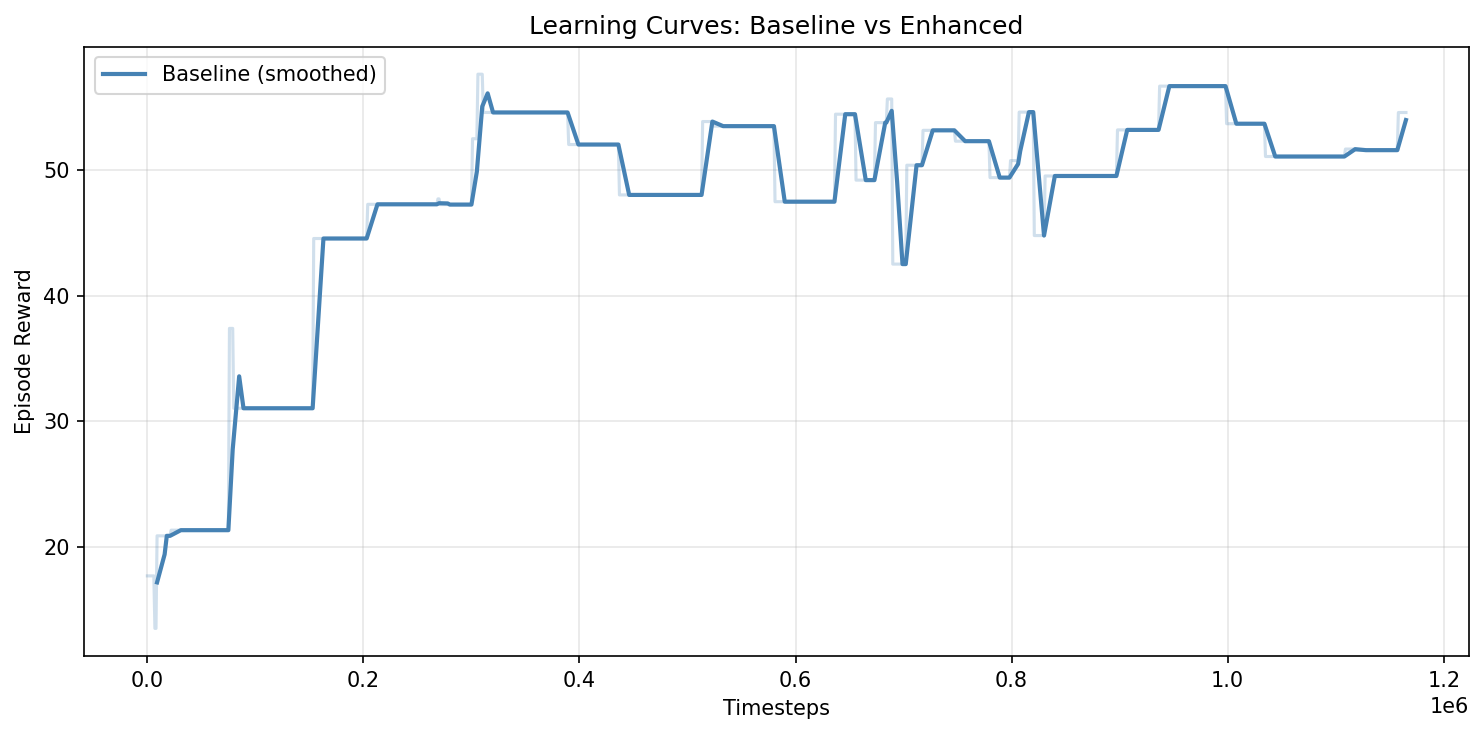


--- collision_success_rates.png ---


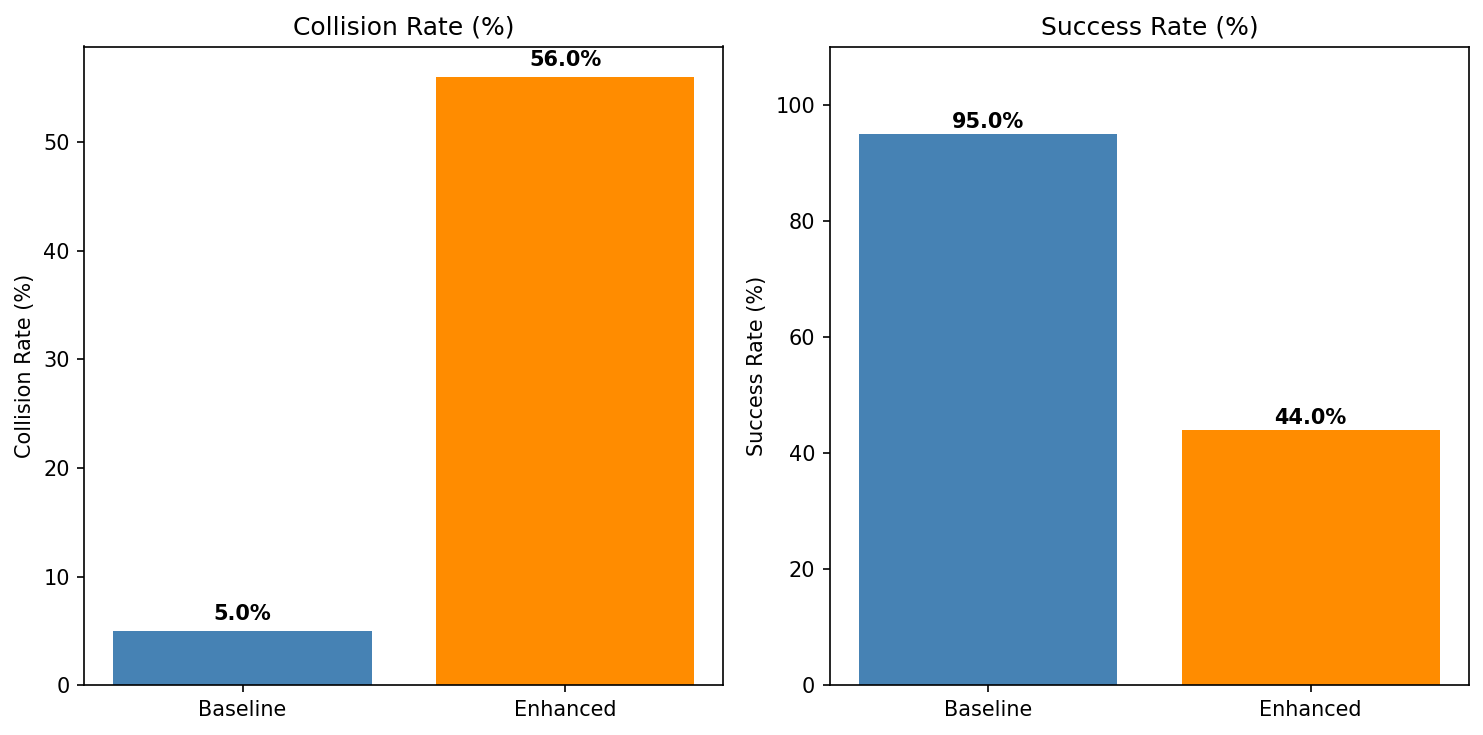


--- reward_distribution.png ---


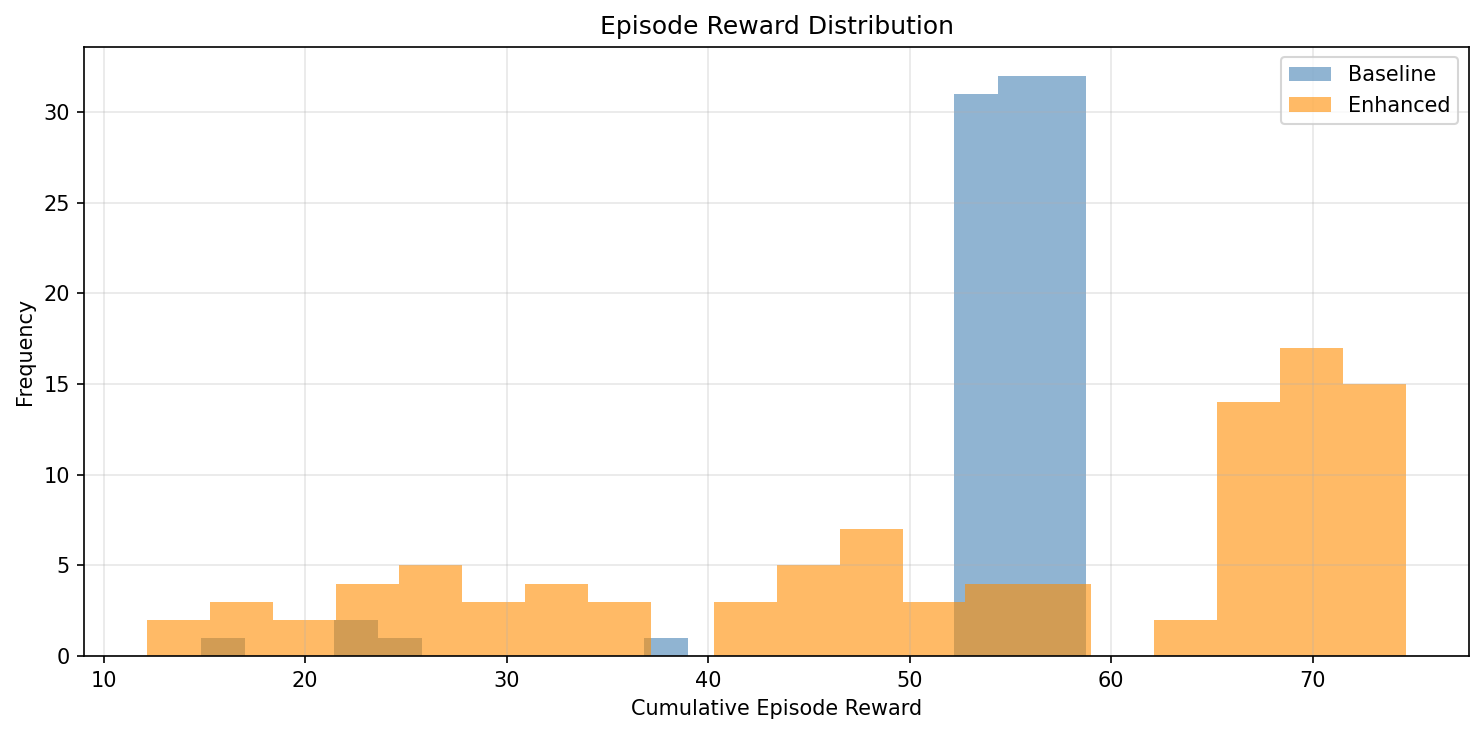


--- lane_deviation_boxplot.png ---


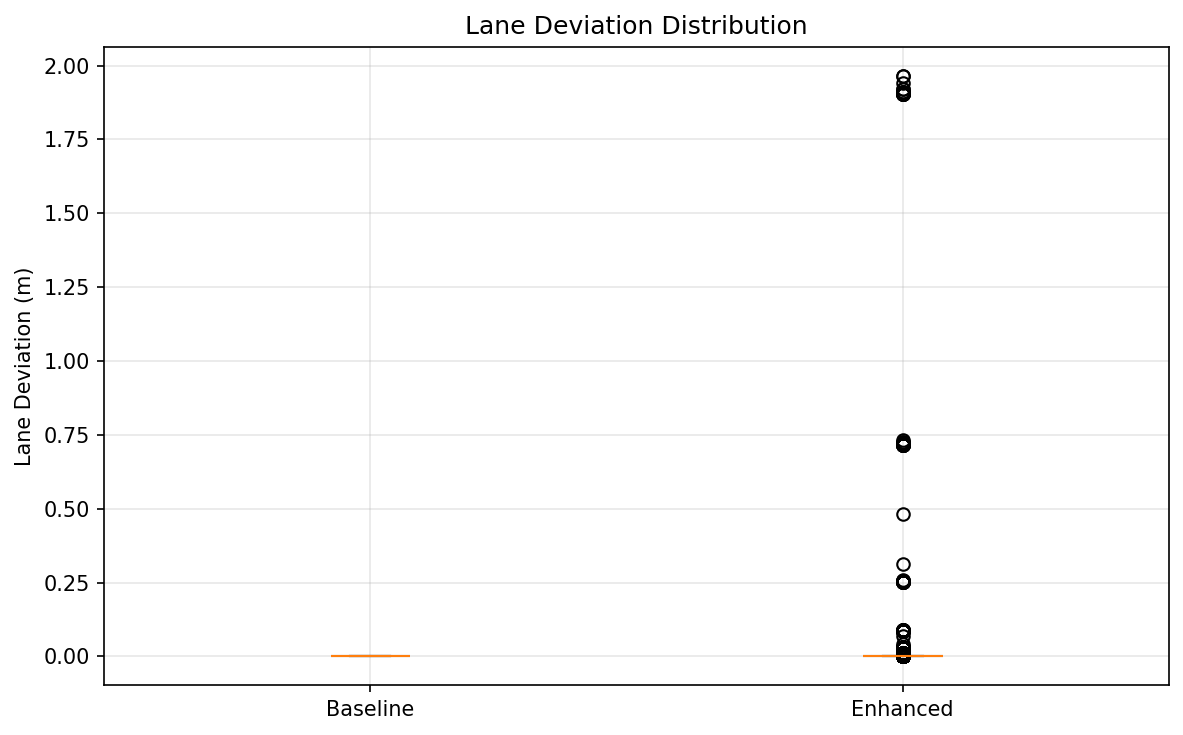


--- speed_profile.png ---


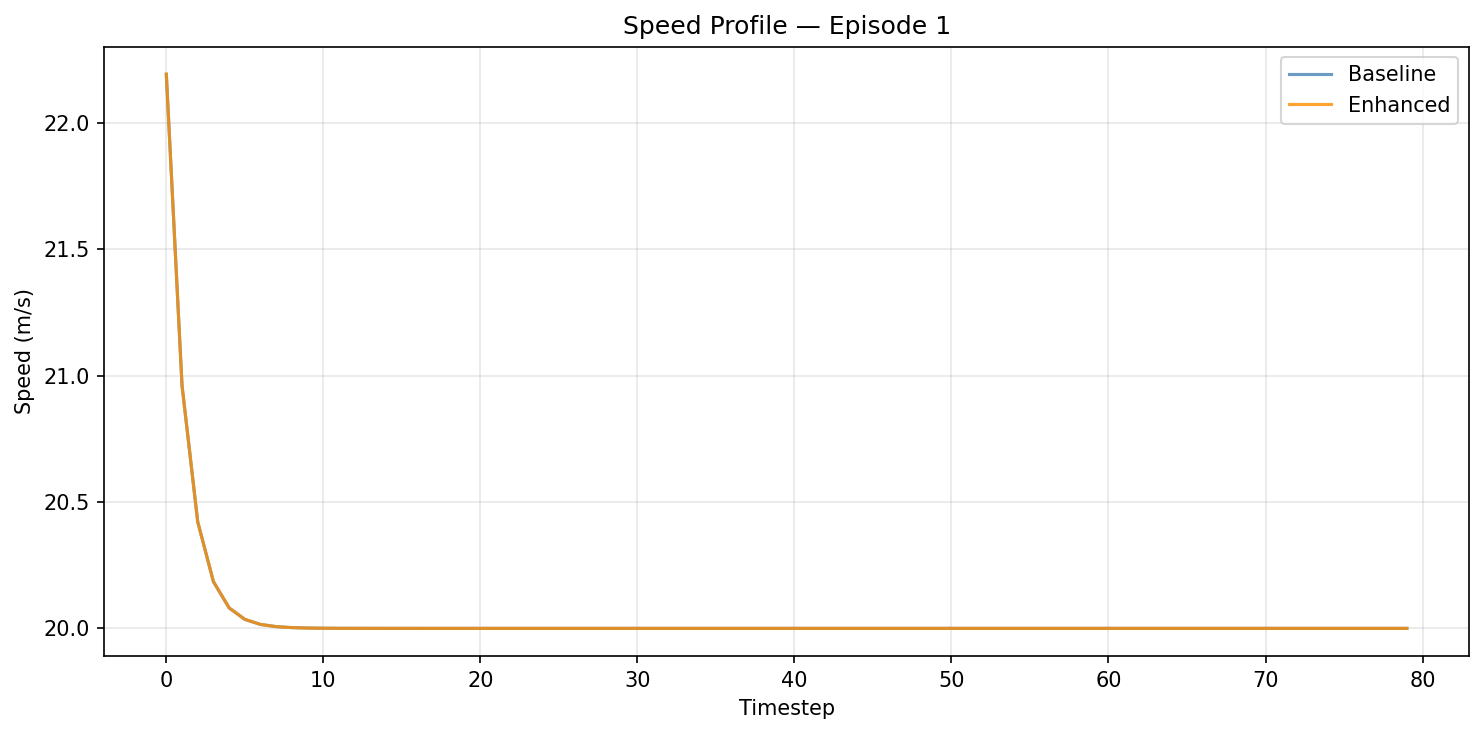


--- jerk_profile.png ---


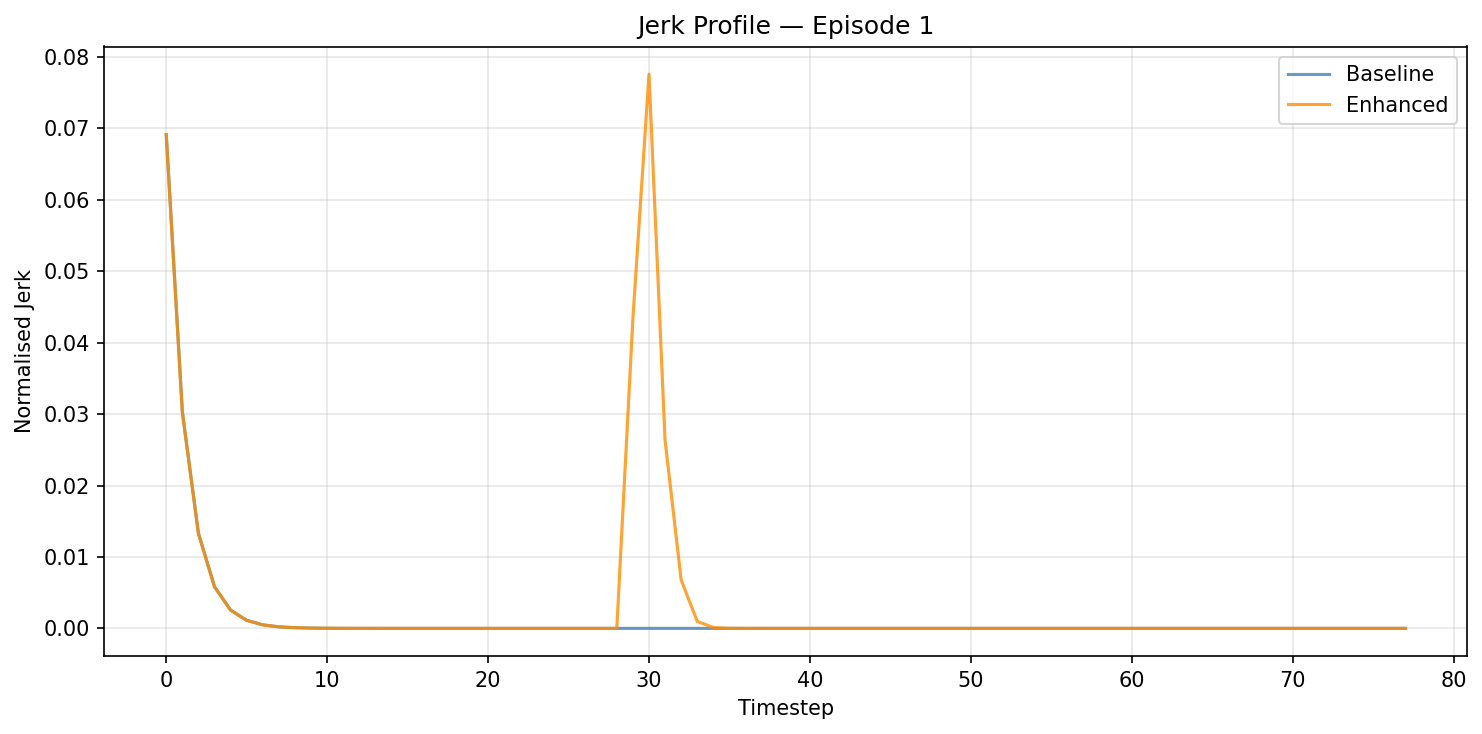

In [25]:
plotter = MetricsPlotter(save_dir=RESULTS_DIR)

# Learning curves (reward collected during training)
plotter.plot_learning_curves(
    baseline_rewards=baseline_reward_log,
    enhanced_rewards=enhanced_reward_log,
    timestep_interval=1000,
)

# All other comparison plots
plotter.plot_bar_comparison(baseline_agg, enhanced_agg)
plotter.plot_reward_distribution(baseline_eps, enhanced_eps)
plotter.plot_lane_deviation_boxplot(baseline_eps, enhanced_eps)
plotter.plot_speed_profile(baseline_eps, enhanced_eps)
plotter.plot_jerk_profile(baseline_eps, enhanced_eps)

print('All plots saved to', RESULTS_DIR)

# Display all plots inline
plot_files = [
    'learning_curves.png',
    'collision_success_rates.png',
    'reward_distribution.png',
    'lane_deviation_boxplot.png',
    'speed_profile.png',
    'jerk_profile.png',
]

for fname in plot_files:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        print(f'\n--- {fname} ---')
        display(Image(filename=fpath))

---
## Step 8 — Final summary table
All 8 metrics side by side for baseline vs enhanced.

In [26]:
plotter.print_summary_table(baseline_agg, enhanced_agg)

# Also show learning efficiency metric
b_eff = compute_learning_efficiency(baseline_reward_log, target_reward=30.0, window=10, timestep_interval=1000)
e_eff = compute_learning_efficiency(enhanced_reward_log, target_reward=30.0, window=10, timestep_interval=1000)

print(f'Learning Efficiency (timesteps to reach reward > 30 sustained over 10 episodes):')
print(f'  Baseline : {b_eff if b_eff else "Never reached target"}')
print(f'  Enhanced : {e_eff if e_eff else "Never reached target"}')


METRIC                                 BASELINE         ENHANCED
Mean Reward                        54.53 ± 7.49    53.01 ± 18.84
Collision Rate                            5.0 %           56.0 %
Success Rate                             95.0 %           44.0 %
Mean Lane Dev (m)                         0.000            0.012
Max Lane Dev (m)                          0.000            1.966
Mean Speed (m/s)                          20.05            20.09
Speed Variance                            0.086            0.536
Mean Jerk                                0.0022           0.0089
Mean Distance (m)                         717.7            565.5

Learning Efficiency (timesteps to reach reward > 30 sustained over 10 episodes):
  Baseline : 83000
  Enhanced : Never reached target


---
## (Optional) Ablation study
Re-train the enhanced model with individual enhancements disabled to see which one contributes the most.

Edit the `ablation_configs` dict and re-run the cell.

In [ ]:
# Each entry disables one enhancement at a time
ablation_configs = {
    'no_reward_shaping':    {**ENHANCEMENTS, 'enhanced_reward':        False},
    'no_dynamic_traffic':   {**ENHANCEMENTS, 'dynamic_traffic':        False},
    'no_obs_enrichment':    {**ENHANCEMENTS, 'observation_enrichment': False},
    'no_attention_reg':     {**ENHANCEMENTS, 'attention_reg':          False},
}

# This cell just prints the configs — uncomment the loop below to actually train them
print('Ablation configs defined:')
for name, cfg in ablation_configs.items():
    disabled = [k for k, v in cfg.items() if not v]
    print(f'  {name:<30} disabled={disabled}')

# ---- Uncomment to run ablation training (takes a long time) ----
# ablation_results = {}
# for ablation_name, enh_cfg in ablation_configs.items():
#     print(f'\nTraining ablation: {ablation_name}')
#     abl_env = make_vec_env(
#         make_enhanced_env, n_envs=N_CPU, seed=SEED, vec_env_cls=DummyVecEnv,
#         env_kwargs={'enhancements': enh_cfg, **env_kwargs},
#     )
#     ModelCls = AttentionRegularizedPPO if enh_cfg.get('attention_reg') else PPO
#     abl_model = ModelCls('MlpPolicy', abl_env, n_steps=128, batch_size=64,
#                          learning_rate=2e-3, verbose=0, device=DEVICE)
#     abl_model.learn(total_timesteps=TOTAL_TIMESTEPS)
#     abl_model.save(os.path.join(LOG_DIR, f'ablation_{ablation_name}'))
#     abl_eval_env = make_enhanced_env(enhancements=enh_cfg, **env_kwargs)
#     abl_eval = MetricsEvaluator(abl_eval_env, abl_model, n_episodes=50)
#     ablation_results[ablation_name] = abl_eval.evaluate()
#     abl_eval_env.close()
#     abl_env.close()
# print('Ablation complete:', ablation_results)

---
## (Optional) TensorBoard
View live training curves during or after training.

In [27]:
# Run this cell to launch TensorBoard inside the notebook (Colab-compatible)
%load_ext tensorboard
%tensorboard --logdir ../enhanced_ppo_logs